<a href="https://colab.research.google.com/github/poojithaveeramalla559-star/Dissertation/blob/main/Poojitha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Required Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualization (useful later)
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Ignore warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Install KaggleHub (if not installed)

!pip install kagglehub

# Import KaggleHub
import kagglehub

print("KaggleHub installed and imported.")

KaggleHub installed and imported.


In [ ]:
# Download PaySim Dataset

# Download latest version of dataset
path = kagglehub.dataset_download("ealaxi/paysim1")

# Print dataset location
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'paysim1' dataset.
Path to dataset files: /kaggle/input/paysim1


In [ ]:
# Load Dataset into DataFrame

import os

# List files in the downloaded directory
files = os.listdir(path)
print("Files in dataset folder:", files)

# Load the CSV file (adjust filename if needed)
file_path = os.path.join(path, files[0])

df = pd.read_csv(file_path)

# Display first 5 rows
df.head()

Files in dataset folder: ['PS_20174392719_1491204439457_log.csv']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
# Basic Data Exploration

# Shape of dataset
print("Dataset shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types and missing values
print("\nDataset Info:")
df.info()

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

Dataset shape: (6362620, 11)

Columns:
 Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB

Missing Values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0

In [ ]:
# Create a Balanced Sample Dataset

# Check original class distribution
print("Original Class Distribution:\n", df['isFraud'].value_counts())

# Separate fraud and non-fraud transactions
fraud_df = df[df['isFraud'] == 1]
nonfraud_df = df[df['isFraud'] == 0]

print("\nFraud cases:", len(fraud_df))
print("Non-Fraud cases:", len(nonfraud_df))

Original Class Distribution:
 isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud cases: 8213
Non-Fraud cases: 6354407


In [ ]:
# Create 100K Dataset (All Fraud Included)

# Total desired size
TARGET_SIZE = 100000

# Separate fraud and non-fraud
fraud_df = df[df['isFraud'] == 1]
nonfraud_df = df[df['isFraud'] == 0]

# Count fraud cases
fraud_count = len(fraud_df)

print("Fraud cases:", fraud_count)

# Calculate required non-fraud samples
nonfraud_needed = TARGET_SIZE - fraud_count

print("Non-fraud samples to select:", nonfraud_needed)

# Sample non-fraud data
nonfraud_sample = nonfraud_df.sample(n=nonfraud_needed, random_state=42)

# Combine datasets
sampled_df = pd.concat([fraud_df, nonfraud_sample])

# Shuffle dataset
sampled_df = sampled_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Final check
print("\nFinal Dataset Shape:", sampled_df.shape)
print("\nClass Distribution:\n", sampled_df['isFraud'].value_counts())

# Preview
sampled_df.head()

Fraud cases: 8213
Non-fraud samples to select: 91787

Final Dataset Shape: (100000, 11)

Class Distribution:
 isFraud
0    91787
1     8213
Name: count, dtype: int64


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,492,PAYMENT,29609.41,C1706979999,148474.00,118864.59,M941522894,0.00,0.00,0,0
1,235,PAYMENT,8955.26,C285074873,121622.00,112666.74,M750034049,0.00,0.00,0,0
2,401,CASH_IN,314852.88,C710822791,34245.00,349097.88,C1226923698,0.00,0.00,0,0
3,140,TRANSFER,1405483.76,C325106229,448.00,0.00,C1414915255,0.00,1405483.76,0,0
4,305,CASH_IN,101137.19,C1035519181,27510601.77,27611738.96,C1460364262,614194.12,513056.93,0,0


In [ ]:
# Basic Data Exploration

# Shape of dataset
print("Dataset shape:", sampled_df.shape)

# Column names
print("\nColumns:\n", sampled_df.columns)

# Data types and missing values
print("\nDataset Info:")
sampled_df.info()

# Check missing values
print("\nMissing Values:\n", sampled_df.isnull().sum())

Dataset shape: (100000, 11)

Columns:
 Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            100000 non-null  int64  
 1   type            100000 non-null  object 
 2   amount          100000 non-null  float64
 3   nameOrig        100000 non-null  object 
 4   oldbalanceOrg   100000 non-null  float64
 5   newbalanceOrig  100000 non-null  float64
 6   nameDest        100000 non-null  object 
 7   oldbalanceDest  100000 non-null  float64
 8   newbalanceDest  100000 non-null  float64
 9   isFraud         100000 non-null  int64  
 10  isFlaggedFraud  100000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memo

In [ ]:
# Data Preprocessing

data = sampled_df.copy()

# 1. Drop ID Columns
data.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

# 2. REMOVE Direct Leakage Column
# isFlaggedFraud is rule-based → must be removed
data.drop(['isFlaggedFraud'], axis=1, inplace=True)


# 3. Encode categorical variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['type'] = le.fit_transform(data['type'])


# 4. Define Features and Target
X = data.drop('isFraud', axis=1)
y = data['isFraud']


# 5. Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Preprocessing (Leakage-Safe) Completed")

Preprocessing (Leakage-Safe) Completed


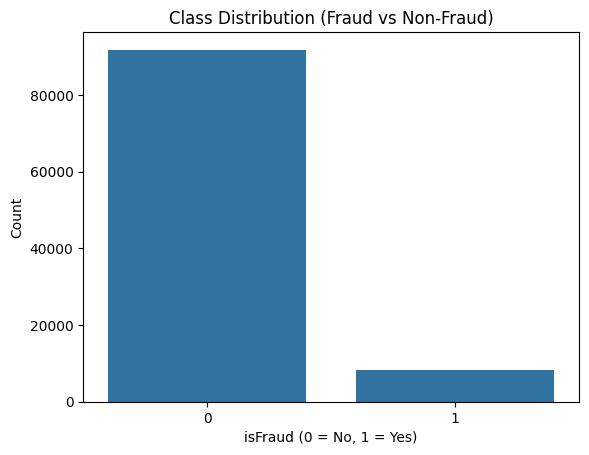

Percentage Distribution:
 isFraud
0    91.787
1     8.213
Name: proportion, dtype: float64


In [ ]:
# Class Distribution

import matplotlib.pyplot as plt
import seaborn as sns

# Count plot
sns.countplot(x='isFraud', data=sampled_df)
plt.title("Class Distribution (Fraud vs Non-Fraud)")
plt.xlabel("isFraud (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# Percentage distribution
fraud_percent = sampled_df['isFraud'].value_counts(normalize=True) * 100
print("Percentage Distribution:\n", fraud_percent)

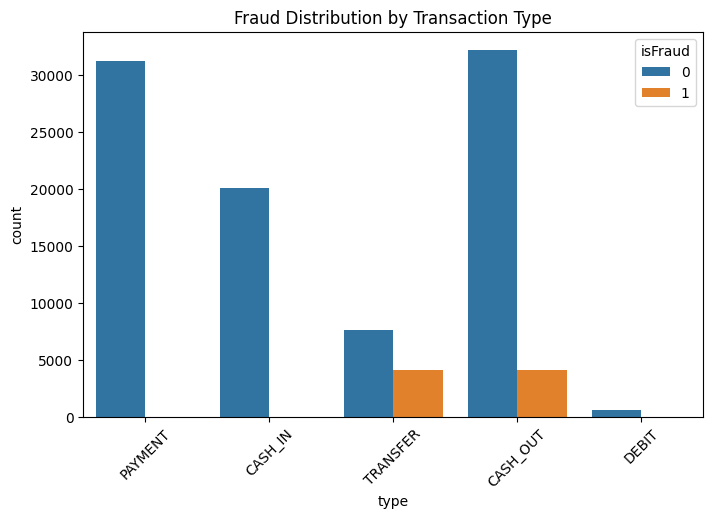


Fraud Rate by Transaction Type:
 type
TRANSFER    0.348681
CASH_OUT    0.113367
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


In [ ]:
# Fraud by Transaction Type

plt.figure(figsize=(8,5))
sns.countplot(x='type', hue='isFraud', data=sampled_df)
plt.title("Fraud Distribution by Transaction Type")
plt.xticks(rotation=45)
plt.show()

# Fraud rate per type
fraud_rate = sampled_df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
print("\nFraud Rate by Transaction Type:\n", fraud_rate)

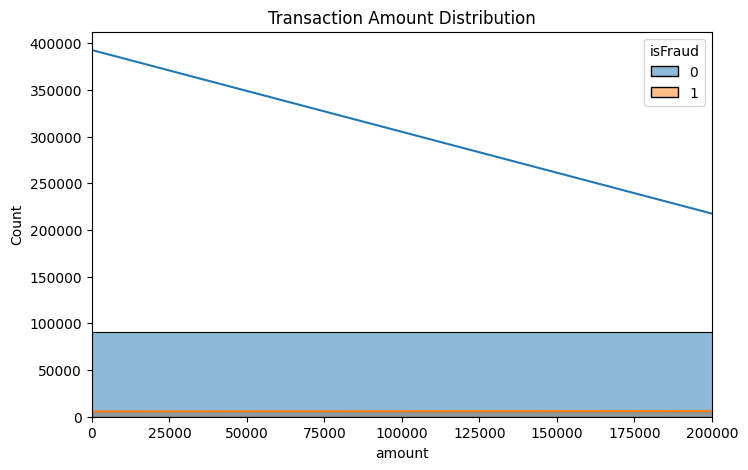

In [ ]:
# Transaction Amount Distribution

plt.figure(figsize=(8,5))
sns.histplot(data=sampled_df, x='amount', hue='isFraud', bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlim(0, 200000)  # limit for readability
plt.show()

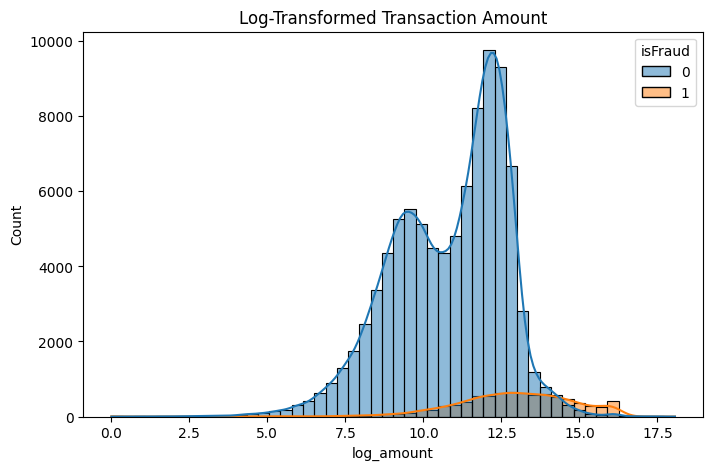

In [ ]:
# Log Transformed Amount

import numpy as np

sampled_df['log_amount'] = np.log1p(sampled_df['amount'])

plt.figure(figsize=(8,5))
sns.histplot(data=sampled_df, x='log_amount', hue='isFraud', bins=50, kde=True)
plt.title("Log-Transformed Transaction Amount")
plt.show()

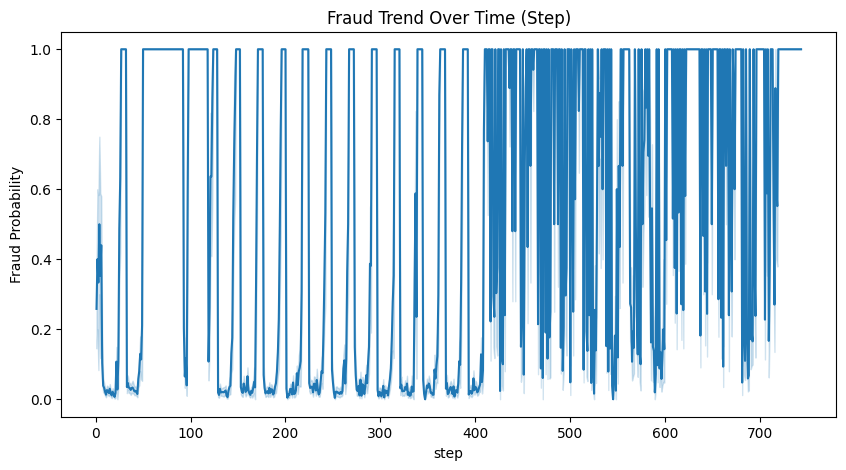

In [ ]:
# Fraud Trend Over Time

plt.figure(figsize=(10,5))
sns.lineplot(data=sampled_df, x='step', y='isFraud')
plt.title("Fraud Trend Over Time (Step)")
plt.ylabel("Fraud Probability")
plt.show()

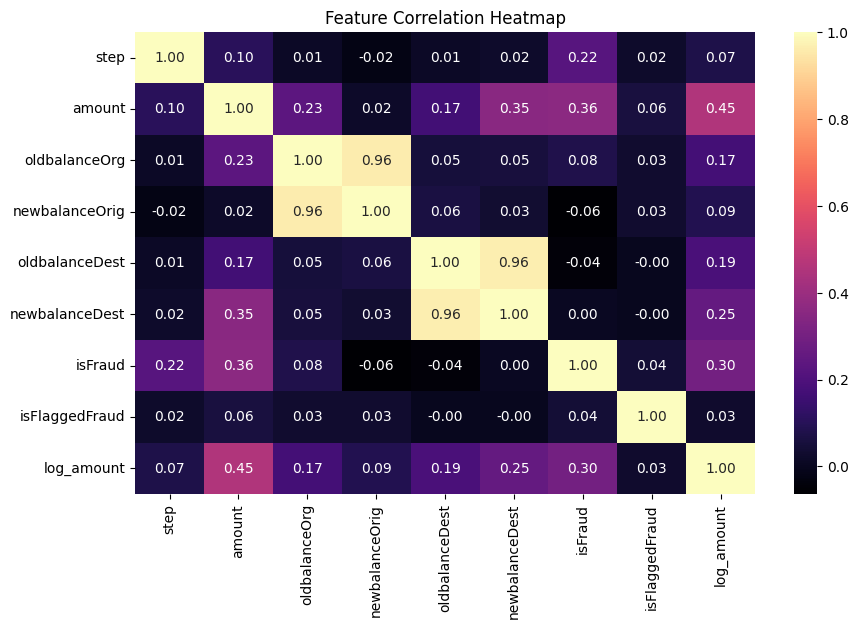

In [ ]:
# Correlation Heatmap

# Create a copy
temp_df = sampled_df.copy()

# Encode 'type' (categorical → numeric)
temp_df['type'] = temp_df['type'].astype('category').cat.codes

# Select only numeric columns
numeric_df = temp_df.select_dtypes(include=['int64', 'float64'])

# Compute correlation
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='magma')
plt.title("Feature Correlation Heatmap")
plt.show()

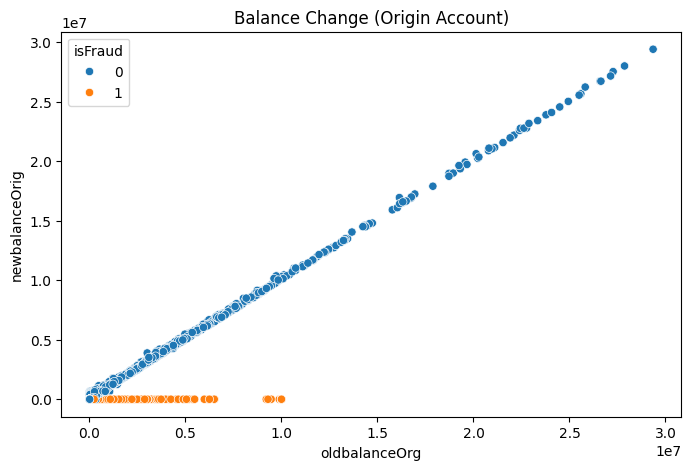

In [ ]:
# Balance Change Patterns

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=sampled_df.sample(5000),  # sample for speed
    x='oldbalanceOrg',
    y='newbalanceOrig',
    hue='isFraud'
)
plt.title("Balance Change (Origin Account)")
plt.show()

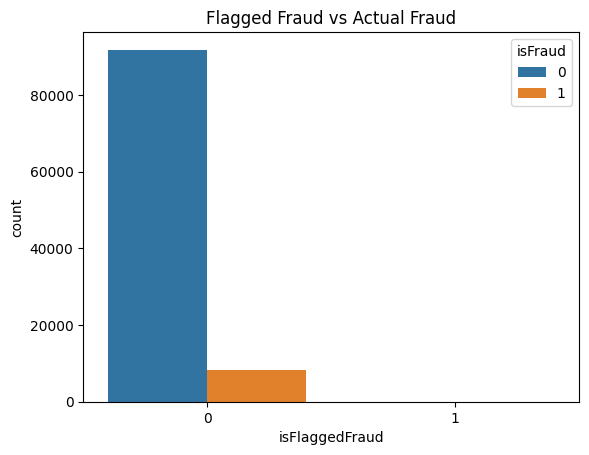


Crosstab:
 isFraud             0     1
isFlaggedFraud             
0               91787  8197
1                   0    16


In [ ]:
# Flagged vs Actual Fraud

sns.countplot(x='isFlaggedFraud', hue='isFraud', data=sampled_df)
plt.title("Flagged Fraud vs Actual Fraud")
plt.show()

print("\nCrosstab:\n", pd.crosstab(sampled_df['isFlaggedFraud'], sampled_df['isFraud']))

In [ ]:
# Feature Engineering

X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# 1. Balance Difference
# Avoid stacking too many rule-based features

X_train_fe['orig_balance_diff'] = X_train_fe['oldbalanceOrg'] - X_train_fe['newbalanceOrig']
X_test_fe['orig_balance_diff'] = X_test_fe['oldbalanceOrg'] - X_test_fe['newbalanceOrig']


# 2. Zero Indicator
X_train_fe['orig_zero'] = (X_train_fe['oldbalanceOrg'] <= 0).astype(int)
X_test_fe['orig_zero'] = (X_test_fe['oldbalanceOrg'] <= 0).astype(int)


# 3. Safer Ratio Feature
epsilon = 1e-3

X_train_fe['amount_to_balance'] = X_train_fe['amount'] / (X_train_fe['oldbalanceOrg'] + epsilon)
X_test_fe['amount_to_balance'] = X_test_fe['amount'] / (X_test_fe['oldbalanceOrg'] + epsilon)

# Clip extreme values
X_train_fe['amount_to_balance'] = X_train_fe['amount_to_balance'].clip(0, 10)
X_test_fe['amount_to_balance'] = X_test_fe['amount_to_balance'].clip(0, 10)


# 4. Log Feature
import numpy as np

X_train_fe['log_amount'] = np.log1p(X_train_fe['amount'])
X_test_fe['log_amount'] = np.log1p(X_test_fe['amount'])

print("Feature Engineering (Leakage-Controlled) Completed")

Feature Engineering (Leakage-Controlled) Completed


In [ ]:
# Compute Class Weights

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

class_weights = dict(zip(classes, weights))

print("Class Weights:", class_weights)

Class Weights: {np.int64(0): np.float64(0.5447364837259976), np.int64(1): np.float64(6.0882800608828)}


In [ ]:
# Decision Tree Model

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=10,
    class_weight=class_weights,
    random_state=42
)

dt_model.fit(X_train_fe, y_train)

y_pred_dt = dt_model.predict(X_test_fe)

In [ ]:
# Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight=class_weights,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_fe, y_train)

y_pred_rf = rf_model.predict(X_test_fe)

In [ ]:
# Gradient Boosting Model

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train_fe, y_train)

y_pred_gb = gb_model.predict(X_test_fe)

In [ ]:
# Advanced Evaluation Function

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score
)

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def evaluate_model_full(model, X_test, y_test, model_name):

    print(f"\n{'='*10} {model_name} {'='*10}")

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities (needed for curves)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)


    # Core Metrics
    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred))

    print("\n--- Key Metrics ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall (Fraud Detection Rate):", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))


    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    TN, FP, FN, TP = cm.ravel()

    print("\n--- Error Breakdown ---")
    print("True Positives (Fraud detected):", TP)
    print("False Negatives (Missed fraud ❌):", FN)
    print("False Positives (False alarms):", FP)
    print("True Negatives:", TN)


    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.title(f"{model_name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)

    plt.figure()
    plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()


    # Error Analysis

    # Identify misclassified samples
    errors = X_test.copy()
    errors['Actual'] = y_test.values
    errors['Predicted'] = y_pred

    false_negatives = errors[(errors['Actual'] == 1) & (errors['Predicted'] == 0)]
    false_positives = errors[(errors['Actual'] == 0) & (errors['Predicted'] == 1)]

    print("\n--- Error Analysis ---")
    print("False Negatives (Missed Fraud):", len(false_negatives))
    print("False Positives:", len(false_positives))

    # Show sample errors
    print("\nSample False Negatives:")
    display(false_negatives.head())

    print("\nSample False Positives:")
    display(false_positives.head())


========== Decision Tree ==========

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18357
           1       0.99      0.99      0.99      1643

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000


--- Key Metrics ---
Accuracy: 0.999
Precision: 0.9939135727328059
Recall (Fraud Detection Rate): 0.9939135727328059
F1 Score: 0.9939135727328059
Balanced Accuracy: 0.996684410705892


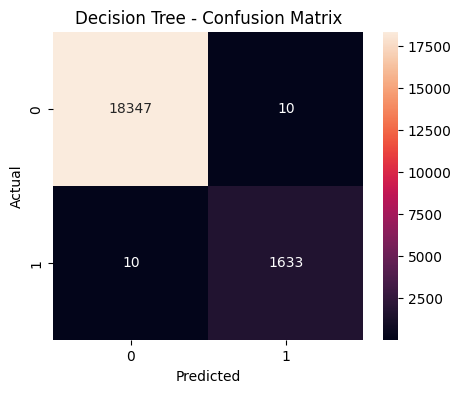


--- Error Breakdown ---
True Positives (Fraud detected): 1633
False Negatives (Missed fraud ❌): 10
False Positives (False alarms): 10
True Negatives: 18347


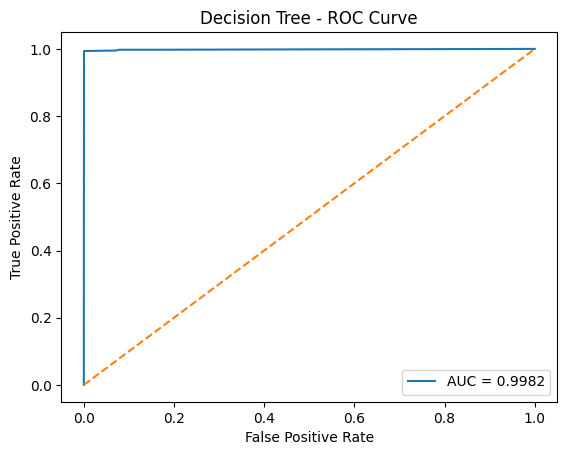

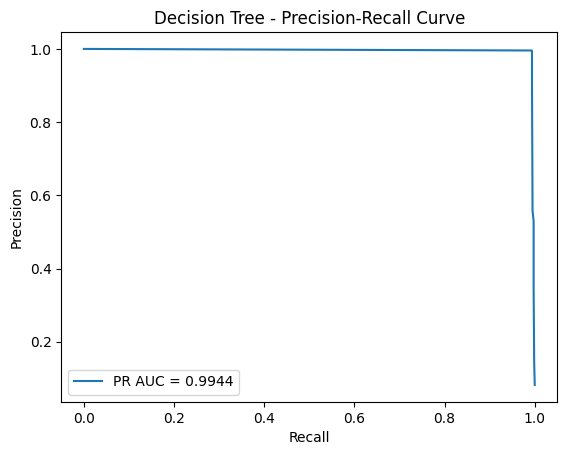


--- Error Analysis ---
False Negatives (Missed Fraud): 10
False Positives: 10

Sample False Negatives:


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_diff,orig_zero,amount_to_balance,log_amount,Actual,Predicted
96908,65,1,215.83,215.83,0.0,3563442.24,3563658.07,215.83,0,0.999995,5.379114,1,0
7588,413,1,781.93,781.93,0.0,0.00,781.93,781.93,0,0.999999,6.663043,1,0
11280,351,1,63.80,63.80,0.0,0.00,63.80,63.80,0,0.999984,4.171306,1,0
93020,18,4,11481.00,11481.00,0.0,0.00,263492.28,11481.00,0,1.000000,9.348536,1,0
50351,8,1,181728.11,0.00,0.0,11397.00,184477.77,0.00,1,10.000000,12.110272,1,0



Sample False Positives:


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_diff,orig_zero,amount_to_balance,log_amount,Actual,Predicted
80678,284,4,1120.38,72201.0,71080.62,0.00,1120.38,1120.38,0,0.015518,7.022315,0,1
83027,228,3,491.34,14610.0,14118.66,0.00,0.00,491.34,0,0.033630,6.199170,0,1
75856,46,3,490.47,16167.0,15676.53,0.00,0.00,490.47,0,0.030338,6.197401,0,1
49777,384,4,121.46,23465.0,23343.54,93360.28,93481.74,121.46,0,0.005176,4.807784,0,1
74652,11,4,1091671.21,16315.0,0.00,0.00,1091671.21,16315.00,0,10.000000,13.903221,0,1


In [ ]:
evaluate_model_full(dt_model, X_test_fe, y_test, "Decision Tree")


========== Random Forest ==========

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18357
           1       1.00      1.00      1.00      1643

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000


--- Key Metrics ---
Accuracy: 0.99985
Precision: 1.0
Recall (Fraud Detection Rate): 0.9981740718198417
F1 Score: 0.9990862016448371
Balanced Accuracy: 0.9990870359099209


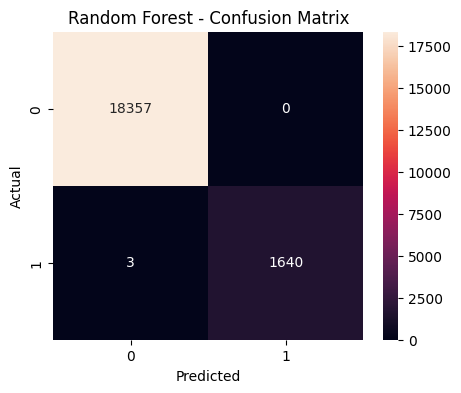


--- Error Breakdown ---
True Positives (Fraud detected): 1640
False Negatives (Missed fraud ❌): 3
False Positives (False alarms): 0
True Negatives: 18357


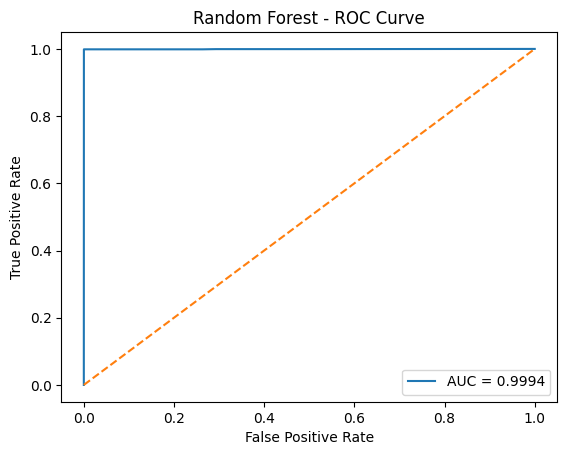

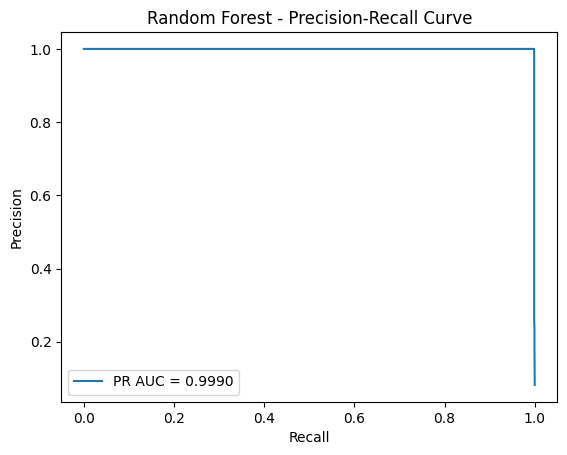


--- Error Analysis ---
False Negatives (Missed Fraud): 3
False Positives: 0

Sample False Negatives:


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_diff,orig_zero,amount_to_balance,log_amount,Actual,Predicted
50351,8,1,181728.11,0.00,0.0,11397.00,184477.77,0.00,1,10.000000,12.110272,1,0
35981,18,1,314251.58,75956.47,0.0,7962205.25,8276456.84,75956.47,0,4.137259,12.657952,1,0
9916,231,1,94372.61,0.00,0.0,471783.48,566156.08,0.00,1,10.000000,11.455017,1,0



Sample False Positives:


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_diff,orig_zero,amount_to_balance,log_amount,Actual,Predicted


In [ ]:
evaluate_model_full(rf_model, X_test_fe, y_test, "Random Forest")


========== Gradient Boosting ==========

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18357
           1       1.00      1.00      1.00      1643

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000


--- Key Metrics ---
Accuracy: 0.9995
Precision: 0.9957498482088646
Recall (Fraud Detection Rate): 0.9981740718198417
F1 Score: 0.9969604863221885
Balanced Accuracy: 0.9988963729475632


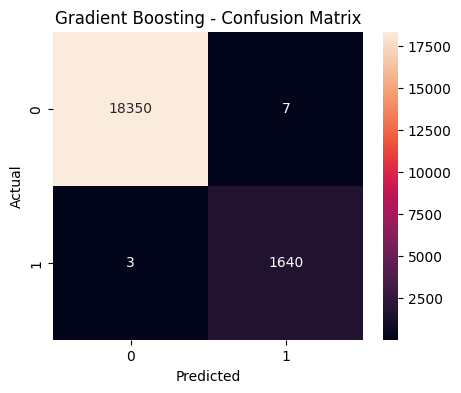


--- Error Breakdown ---
True Positives (Fraud detected): 1640
False Negatives (Missed fraud ❌): 3
False Positives (False alarms): 7
True Negatives: 18350


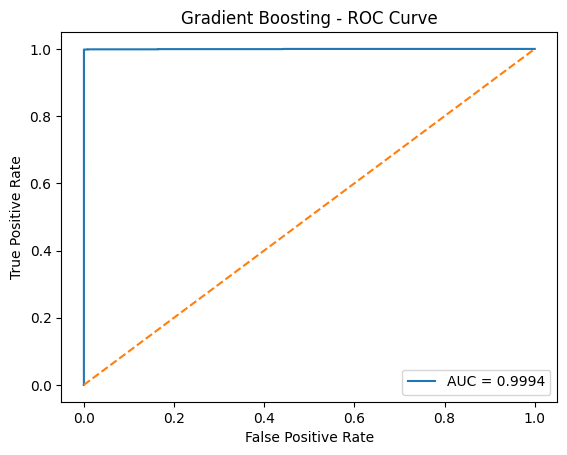

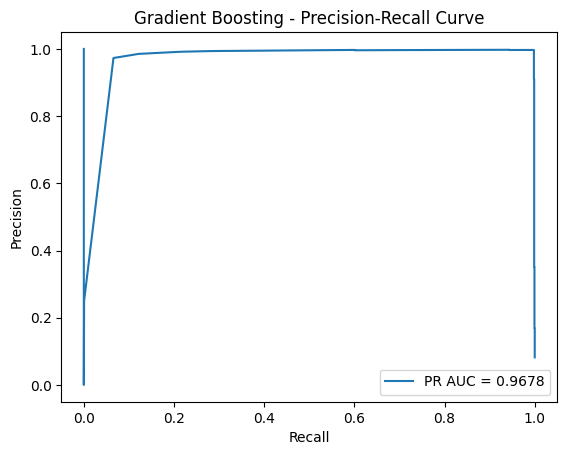


--- Error Analysis ---
False Negatives (Missed Fraud): 3
False Positives: 7

Sample False Negatives:


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_diff,orig_zero,amount_to_balance,log_amount,Actual,Predicted
50351,8,1,181728.11,0.00,0.0,11397.00,184477.77,0.00,1,10.000000,12.110272,1,0
35981,18,1,314251.58,75956.47,0.0,7962205.25,8276456.84,75956.47,0,4.137259,12.657952,1,0
9916,231,1,94372.61,0.00,0.0,471783.48,566156.08,0.00,1,10.000000,11.455017,1,0



Sample False Positives:


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_diff,orig_zero,amount_to_balance,log_amount,Actual,Predicted
72846,140,4,1936584.58,0.0,0.00,3439249.03,5375833.61,0.00,1,10.000000,14.476437,0,1
35103,299,1,29193.93,5062.0,0.00,613782.43,642976.36,5062.00,0,5.767271,10.281750,0,1
16368,1,1,146534.96,21114.0,0.00,0.00,67762.92,21114.00,0,6.940180,11.895026,0,1
97607,356,4,436175.58,436132.0,0.00,0.00,436175.58,436132.00,0,1.000100,12.985802,0,1
89941,614,0,112277.62,13369.0,125646.62,0.00,0.00,-112277.62,0,8.398355,11.628739,0,1


In [ ]:
evaluate_model_full(gb_model, X_test_fe, y_test, "Gradient Boosting")

In [ ]:
# Enhanced Model Comparison Table

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, accuracy_score, balanced_accuracy_score
)

def get_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    # Specificity (True Negative Rate)
    specificity = TN / (TN + FP)

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Balanced Accuracy': balanced_acc,
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN,
        'Specificity': specificity
    }


# Compute metrics for each model
dt_metrics = get_metrics(y_test, y_pred_dt)
rf_metrics = get_metrics(y_test, y_pred_rf)
gb_metrics = get_metrics(y_test, y_pred_gb)


# Create DataFrame
results = pd.DataFrame([
    ['Decision Tree', *dt_metrics.values()],
    ['Random Forest', *rf_metrics.values()],
    ['Gradient Boosting', *gb_metrics.values()]
],
columns=['Model'] + list(dt_metrics.keys()))


# Sort by Recall (fraud detection priority)
results = results.sort_values(by='Recall', ascending=False)

results

,Model,Accuracy,Precision,Recall,F1 Score,Balanced Accuracy,TP,FP,FN,TN,Specificity
1,Random Forest,0.99985,1.000000,0.998174,0.999086,0.999087,1640,0,3,18357,1.000000
2,Gradient Boosting,0.99950,0.995750,0.998174,0.996960,0.998896,1640,7,3,18350,0.999619
0,Decision Tree,0.99900,0.993914,0.993914,0.993914,0.996684,1633,10,10,18347,0.999455


In [ ]:
import pandas as pd

importance = rf_model.feature_importances_
feature_names = X_train_fe.columns

feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)
print(feat_imp.head(10))

orig_balance_diff    0.347603
amount_to_balance    0.277988
newbalanceOrig       0.130213
oldbalanceOrg        0.080693
log_amount           0.042280
amount               0.040036
type                 0.039240
step                 0.013718
newbalanceDest       0.011899
orig_zero            0.010802
dtype: float64


In [ ]:
# Threshold Tuning (Random Forest example)

import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score

y_prob = rf_model.predict_proba(X_test_fe)[:, 1]

thresholds = np.linspace(0.1, 0.9, 50)

results_thresh = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    results_thresh.append({
        'threshold': t,
        'recall': recall_score(y_test, y_pred_t),
        'precision': precision_score(y_test, y_pred_t),
        'f1': f1_score(y_test, y_pred_t)
    })

thresh_df = pd.DataFrame(results_thresh)

thresh_df.sort_values(by='recall', ascending=False).head()

,threshold,recall,precision,f1
0,0.100000,0.998783,0.991541,0.995149
1,0.116327,0.998783,0.992140,0.995450
2,0.132653,0.998783,0.993943,0.996357
3,0.148980,0.998783,0.993943,0.996357
4,0.165306,0.998783,0.994545,0.996660


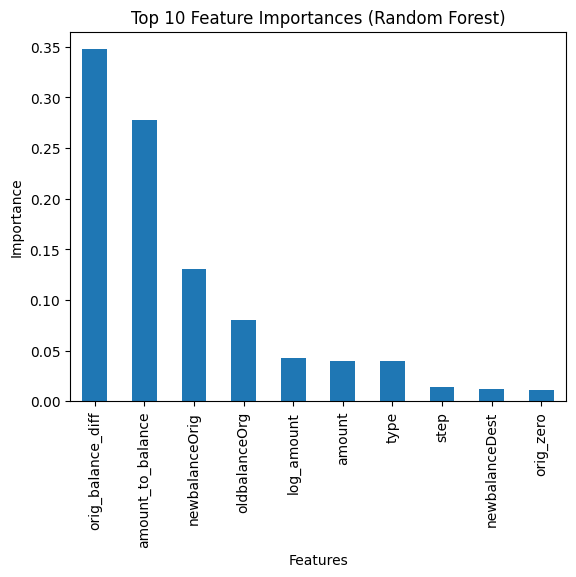

In [ ]:
# Feature Importance Plot

import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X_train_fe.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure()
feat_imp.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [ ]:
# Cross-Validation (Recall Focus)

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_model,
    X_train_fe,
    y_train,
    cv=cv,
    scoring='recall'
)

print("CV Recall Scores:", cv_scores)
print("Mean CV Recall:", cv_scores.mean())

CV Recall Scores: [0.99543379 0.99543379 0.99543379 0.99771689 0.99467275]
Mean CV Recall: 0.9957382039573821


In [ ]:
# Ablation Study (Remove strong features)

cols_remove = [
    'oldbalanceOrg', 'newbalanceOrig',
    'orig_balance_diff',
    'amount_to_balance'
]

X_train_ab = X_train_fe.drop(columns=cols_remove, errors='ignore')
X_test_ab = X_test_fe.drop(columns=cols_remove, errors='ignore')

rf_model_ab = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weights,
    random_state=42
)

rf_model_ab.fit(X_train_ab, y_train)

y_pred_ab = rf_model_ab.predict(X_test_ab)

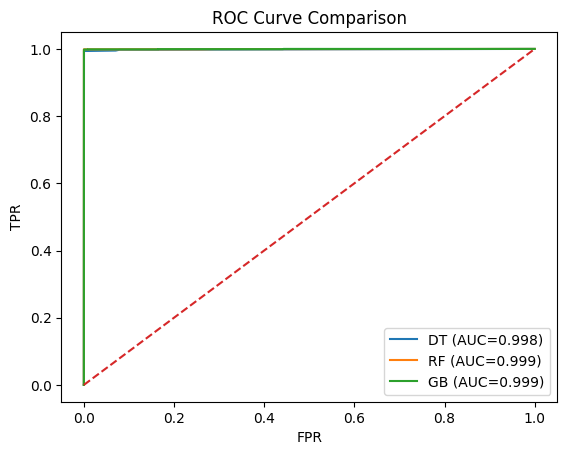

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure()

for model, name in [(dt_model, "DT"), (rf_model, "RF"), (gb_model, "GB")]:
    y_prob = model.predict_proba(X_test_fe)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

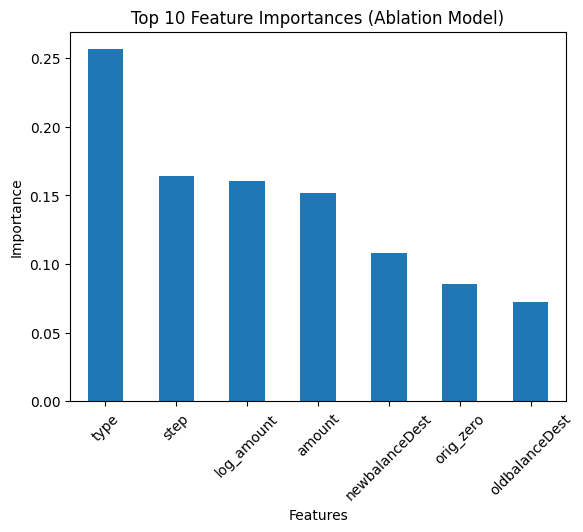


Full Feature Importance:

type              0.256580
step              0.164288
log_amount        0.160892
amount            0.151792
newbalanceDest    0.108417
orig_zero         0.085563
oldbalanceDest    0.072468
dtype: float64


In [ ]:
# Feature Importance - Ablation Model

import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances
importances_ab = rf_model_ab.feature_importances_

# Get feature names from ablation dataset
features_ab = X_train_ab.columns

# Create Series and sort
feat_imp_ab = pd.Series(importances_ab, index=features_ab).sort_values(ascending=False)

# Plot Top 10 features
plt.figure()
feat_imp_ab.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances (Ablation Model)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

# Print full importance list
print("\nFull Feature Importance:\n")
print(feat_imp_ab)

In [ ]:
# False Negative Analysis

errors = X_test_fe.copy()
errors['Actual'] = y_test.values
errors['Predicted'] = y_pred_rf

false_negatives = errors[(errors['Actual'] == 1) & (errors['Predicted'] == 0)]

print("Missed Fraud Cases:", len(false_negatives))
false_negatives.head()

Missed Fraud Cases: 3


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_diff,orig_zero,amount_to_balance,log_amount,Actual,Predicted
50351,8,1,181728.11,0.00,0.0,11397.00,184477.77,0.00,1,10.000000,12.110272,1,0
35981,18,1,314251.58,75956.47,0.0,7962205.25,8276456.84,75956.47,0,4.137259,12.657952,1,0
9916,231,1,94372.61,0.00,0.0,471783.48,566156.08,0.00,1,10.000000,11.455017,1,0



========== Random Forest (Ablation) ==========

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     18357
           1       0.95      0.80      0.87      1643

    accuracy                           0.98     20000
   macro avg       0.96      0.90      0.93     20000
weighted avg       0.98      0.98      0.98     20000


--- Key Metrics ---
Accuracy: 0.9797
Precision: 0.9465703971119134
Recall (Fraud Detection Rate): 0.7979306147291539
F1 Score: 0.8659180977542933
Balanced Accuracy: 0.8969497274767957


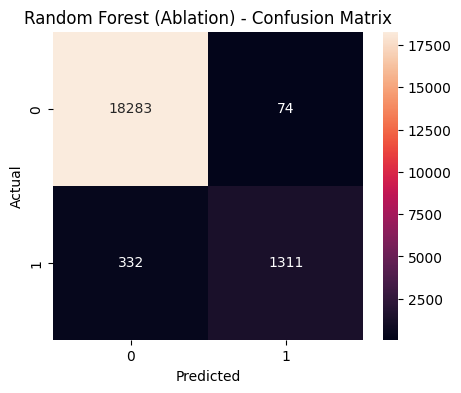


--- Error Breakdown ---
True Positives (Fraud detected): 1311
False Negatives (Missed fraud ❌): 332
False Positives (False alarms): 74
True Negatives: 18283


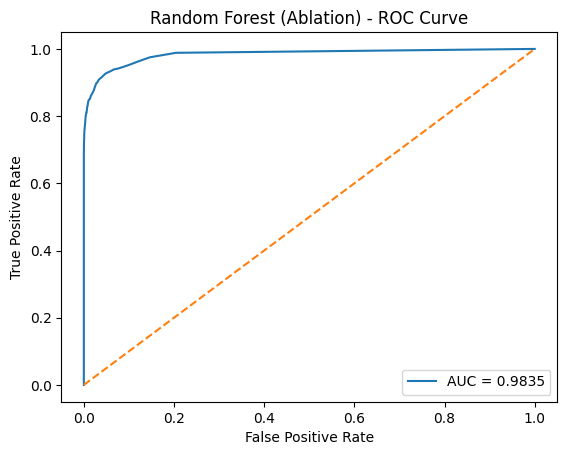

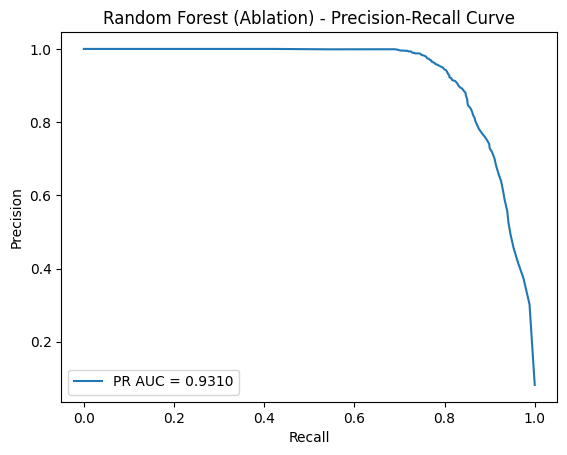


--- Error Analysis ---
False Negatives (Missed Fraud): 332
False Positives: 74

Sample False Negatives:


,step,type,amount,oldbalanceDest,newbalanceDest,orig_zero,log_amount,Actual,Predicted
87057,671,1,152724.32,0.00,152724.32,0,11.936396,1,0
55972,188,1,389214.05,0.00,389214.05,0,12.871887,1,0
35522,208,1,246402.71,51433.96,297836.67,0,12.414727,1,0
68972,374,1,200418.10,902091.87,1102509.97,0,12.208166,1,0
10501,370,1,563149.41,65562.72,628712.13,0,13.241302,1,0



Sample False Positives:


,step,type,amount,oldbalanceDest,newbalanceDest,orig_zero,log_amount,Actual,Predicted
61501,495,1,388438.00,180297.00,568735.00,0,12.869891,0,1
6560,590,1,519251.61,4634249.88,5153501.49,0,13.160146,0,1
89985,448,1,171680.39,0.00,171680.39,0,12.053396,0,1
80678,284,4,1120.38,0.00,1120.38,0,7.022315,0,1
36472,517,1,75416.48,803152.26,878568.75,0,11.230794,0,1


In [ ]:
# Evaluate Ablation Model

evaluate_model_full(
    rf_model_ab,
    X_test_ab,
    y_test,
    "Random Forest (Ablation)"
)

In [ ]:
# Hyperparameter Tuning (Ablation)

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Smaller, focused parameter space
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [8, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_ab = RandomForestClassifier(
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1
)

rf_ab_random = RandomizedSearchCV(
    estimator=rf_ab,
    param_distributions=param_dist,
    n_iter=10,
    scoring='recall',
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_ab_random.fit(X_train_ab, y_train)

print("Best Parameters:", rf_ab_random.best_params_)
print("Best CV Recall:", rf_ab_random.best_score_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 8}
Best CV Recall: 0.8831050228310503


In [ ]:
# Best Tuned Ablation Model

best_rf_ab = rf_ab_random.best_estimator_

y_pred_ab_tuned = best_rf_ab.predict(X_test_ab)
y_prob_ab_tuned = best_rf_ab.predict_proba(X_test_ab)[:, 1]


========== Tuned Random Forest (Ablation) ==========

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     18357
           1       0.79      0.89      0.84      1643

    accuracy                           0.97     20000
   macro avg       0.89      0.93      0.91     20000
weighted avg       0.97      0.97      0.97     20000


--- Key Metrics ---
Accuracy: 0.9713
Precision: 0.78938819707634
Recall (Fraud Detection Rate): 0.887401095556908
F1 Score: 0.8355300859598854
Balanced Accuracy: 0.9331051345845771


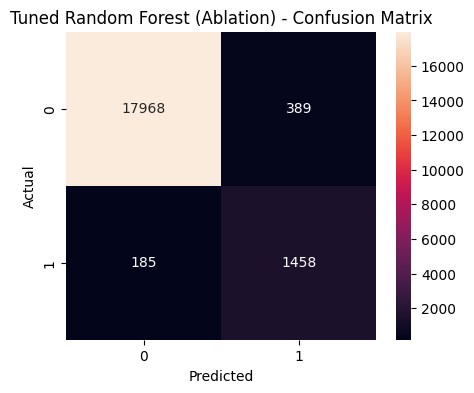


--- Error Breakdown ---
True Positives (Fraud detected): 1458
False Negatives (Missed fraud ❌): 185
False Positives (False alarms): 389
True Negatives: 17968


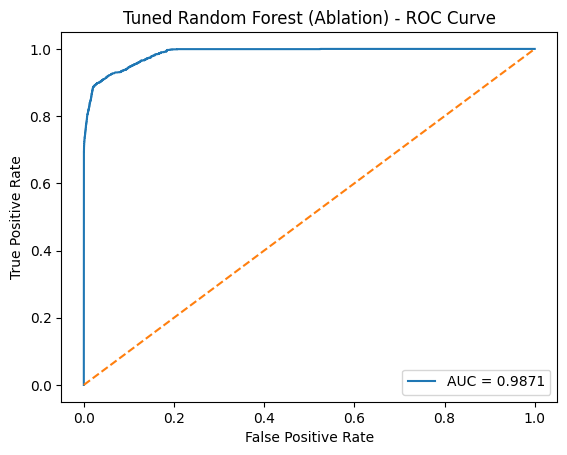

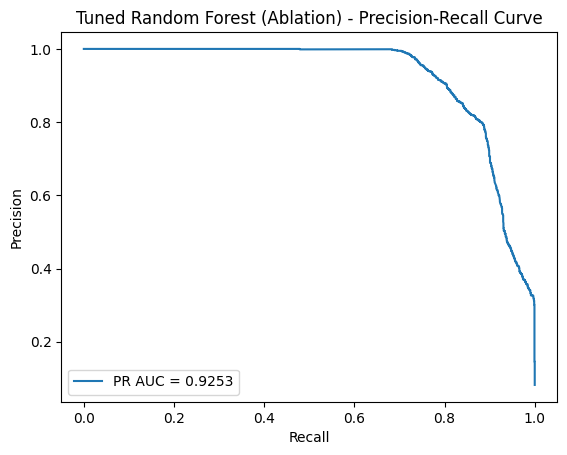


--- Error Analysis ---
False Negatives (Missed Fraud): 185
False Positives: 389

Sample False Negatives:


,step,type,amount,oldbalanceDest,newbalanceDest,orig_zero,log_amount,Actual,Predicted
55972,188,1,389214.05,0.00,389214.05,0,12.871887,1,0
35522,208,1,246402.71,51433.96,297836.67,0,12.414727,1,0
68972,374,1,200418.10,902091.87,1102509.97,0,12.208166,1,0
37085,151,1,258103.59,244362.91,502466.50,0,12.461120,1,0
98899,7,1,441445.58,98993.50,0.00,0,12.997812,1,0



Sample False Positives:


,step,type,amount,oldbalanceDest,newbalanceDest,orig_zero,log_amount,Actual,Predicted
15982,305,1,445851.36,0.00,445851.36,0,13.007743,0,1
23959,252,1,527112.69,0.00,527112.69,0,13.175172,0,1
53319,233,1,469394.97,7644842.75,8114237.72,0,13.059202,0,1
61501,495,1,388438.00,180297.00,568735.00,0,12.869891,0,1
32620,307,1,7257.65,0.00,7257.65,0,8.889949,0,1


In [ ]:
# Evaluate Tuned Ablation Model

evaluate_model_full(
    best_rf_ab,
    X_test_ab,
    y_test,
    "Tuned Random Forest (Ablation)"
)

In [ ]:
# CV for Tuned Ablation Model

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_ab_tuned = cross_val_score(
    best_rf_ab,
    X_train_ab,
    y_train,
    cv=cv,
    scoring='recall'
)

print("Tuned Ablation CV Recall:", cv_scores_ab_tuned)
print("Mean CV Recall:", cv_scores_ab_tuned.mean())

Tuned Ablation CV Recall: [0.87519026 0.88432268 0.87975647 0.88660578 0.88280061]
Mean CV Recall: 0.8817351598173516


In [ ]:
# Enhanced Comparison (3 RF Models)

# Predictions
y_pred_full = rf_model.predict(X_test_fe)
y_pred_ab = rf_model_ab.predict(X_test_ab)
y_pred_ab_tuned = best_rf_ab.predict(X_test_ab)


# Compute metrics
full_metrics = get_metrics(y_test, y_pred_full)
ab_metrics = get_metrics(y_test, y_pred_ab)
ab_tuned_metrics = get_metrics(y_test, y_pred_ab_tuned)


# Create DataFrame
results = pd.DataFrame([
    ['Original RF', *full_metrics.values()],
    ['Ablation RF', *ab_metrics.values()],
    ['Tuned Ablation RF', *ab_tuned_metrics.values()]
],
columns=['Model'] + list(full_metrics.keys()))


# Sort by Recall (priority in fraud detection)
results = results.sort_values(by='Recall', ascending=False)

# Add False Positive Rate and False Negative Rate

results['FPR'] = results['FP'] / (results['FP'] + results['TN'])
results['FNR'] = results['FN'] / (results['FN'] + results['TP'])

results

,Model,Accuracy,Precision,Recall,F1 Score,Balanced Accuracy,TP,FP,FN,TN,Specificity,FPR,FNR
0,Original RF,0.99985,1.000000,0.998174,0.999086,0.999087,1640,0,3,18357,1.000000,0.000000,0.001826
2,Tuned Ablation RF,0.97130,0.789388,0.887401,0.835530,0.933105,1458,389,185,17968,0.978809,0.021191,0.112599
1,Ablation RF,0.97970,0.946570,0.797931,0.865918,0.896950,1311,74,332,18283,0.995969,0.004031,0.202069


In [ ]:
# Confusion Matrix Comparison (All Models)

from sklearn.metrics import confusion_matrix

# Compute confusion matrices
cm_full = confusion_matrix(y_test, y_pred_full)
cm_ab = confusion_matrix(y_test, y_pred_ab)
cm_ab_tuned = confusion_matrix(y_test, y_pred_ab_tuned)


# Function to print labeled matrix
def print_cm(cm, title):
    TN, FP, FN, TP = cm.ravel()
    print(f"\n=== {title} ===")
    print(f"TN: {TN} | FP: {FP}")
    print(f"FN: {FN} | TP: {TP}")


# Print results
print_cm(cm_full, "Original RF")
print_cm(cm_ab, "Ablation RF")
print_cm(cm_ab_tuned, "Tuned Ablation RF")


=== Original RF ===
TN: 18357 | FP: 0
FN: 3 | TP: 1640

=== Ablation RF ===
TN: 18283 | FP: 74
FN: 332 | TP: 1311

=== Tuned Ablation RF ===
TN: 17968 | FP: 389
FN: 185 | TP: 1458
